# Колебания струны и мембраны

## Базовый уровень

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

In [2]:
L = 1.0
c = 1.0
num_modes = 5
n_points = 800

Интегрируем $\ddot u + \omega^2 u = 0$ с начальными условиями $u(0) = 0$, $\dot u(0) = 1$ и возвращаем $u(L)$:

In [3]:
def shoot(omega, L=L):
    def f(x, y):
        return [y[1], - (omega**2) * y[0]]
    sol = solve_ivp(f, [0.0, L], [0.0, 1.0], t_eval=[L])
    return sol.y[0, -1]

In [4]:
def find_mode(n, L=L, c=c):
    guess = n * np.pi * c / L
    a = (n - 0.5) * np.pi * c / L
    b = (n + 0.5) * np.pi * c / L

    fa = shoot(a)
    fb = shoot(b)

    max_expand = 20
    expand_factor = 0.2 * np.pi * c / L
    attempts = 0
    while fa * fb > 0 and attempts < max_expand:
        attempts += 1
        a -= expand_factor
        b += expand_factor
        fa = shoot(a)
        fb = shoot(b)

    if fa * fb > 0:
        omegas_try = np.linspace(max(1e-6, guess - 2*np.pi*c/L), guess + 2*np.pi*c/L, 101)
        vals = np.array([shoot(om) for om in omegas_try])
        idx = np.where(vals[:-1] * vals[1:] < 0)[0]
        a = omegas_try[idx[0]]
        b = omegas_try[idx[0]+1]
        fa = vals[idx[0]]
        fb = vals[idx[0]+1]

    omega_root = brentq(lambda w: shoot(w), a, b, maxiter=200)
    return omega_root

def compute_mode_shape(omega, L=L, points=400):
    def f(x, y):
        return [y[1], - (omega**2) * y[0]]
    xs = np.linspace(0, L, points)
    sol = solve_ivp(f, [0.0, L], [0.0, 1.0], t_eval=xs)
    ys = sol.y[0]
    ys = ys / np.max(np.abs(ys))
    if ys[1] < 0:
        ys = -ys
    return xs, ys

Мода 1: omega = 3.140953073210
Мода 2: omega = 6.281644932646
Мода 3: omega = 9.422170311635
Мода 4: omega = 12.562826784649
Мода 5: omega = 15.703462137191


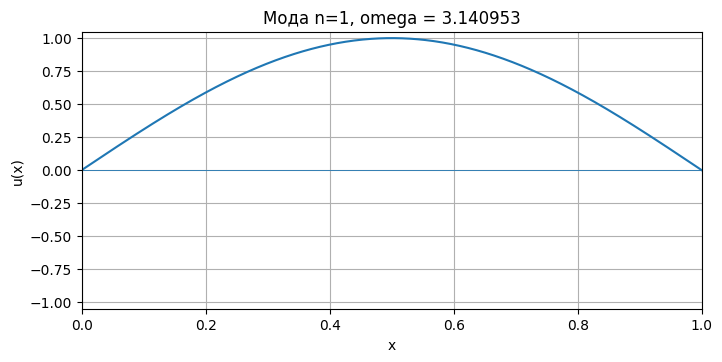

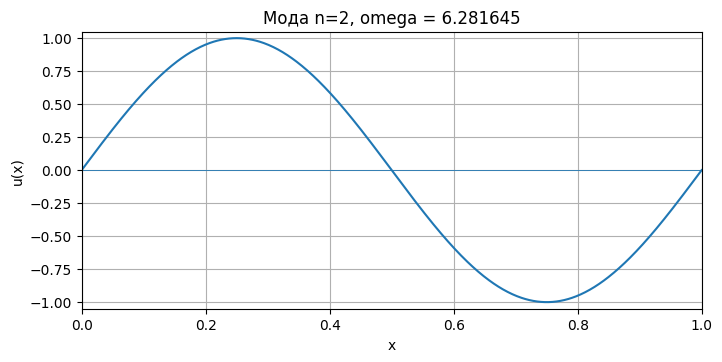

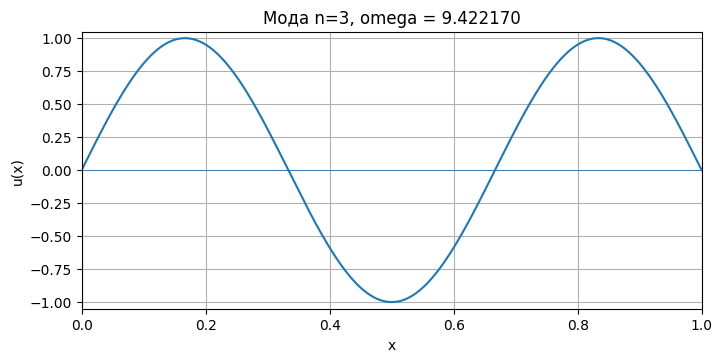

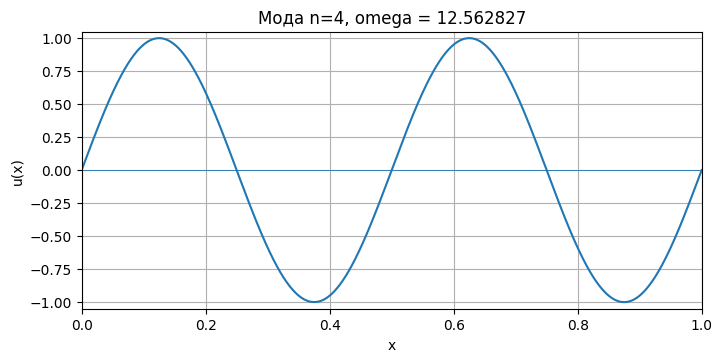

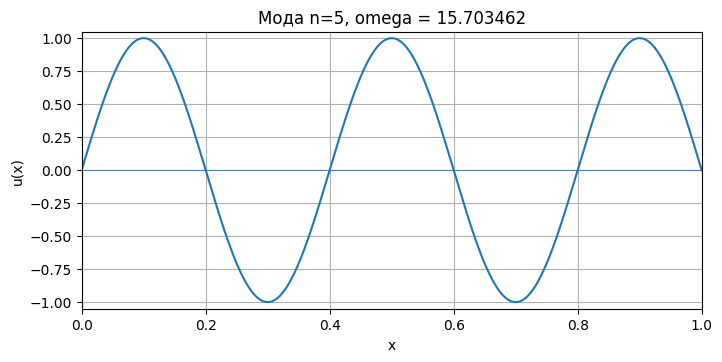

In [5]:
omegas = []
modes = []
for n in range(1, num_modes + 1):
    omega_n = find_mode(n)
    omegas.append(omega_n)
    xs, ys = compute_mode_shape(omega_n, points=n_points)
    modes.append((xs, ys))
    print(f"Мода {n}: omega = {omega_n:.12f}")

for i, (xs, ys) in enumerate(modes, start=1):
    plt.figure(figsize=(8, 3.6))
    plt.plot(xs, ys)
    plt.title(f"Мода n={i}, omega = {omegas[i-1]:.6f}")
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.axhline(0.0, linewidth=0.6)
    plt.xlim(0, L)
    plt.ylim(-1.05, 1.05)
    plt.grid(True)
    plt.show()